# Agentic RAG

https://docs.langchain.com/oss/python/langgraph/agentic-rag

 "![Agentic RAG](https://mintcdn.com/langchain-5e9cc07a/I6RpA28iE233vhYX/images/langgraph-hybrid-rag-tutorial.png?w=840&fit=max&auto=format&n=I6RpA28iE233vhYX&q=85&s=b7626e6ae3cb94fb90a61e6fad69c8ba)"

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

# 1. Indexing
외부 문서를 임베딩을 거쳐 벡터 스토어에 저장

In [2]:
# 문서 전처리
from langchain_community.document_loaders import WebBaseLoader

urls = [
    "https://lilianweng.github.io/posts/2024-11-28-reward-hacking/",
    "https://lilianweng.github.io/posts/2024-07-07-hallucination/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/",
]

docs = [WebBaseLoader(url).load() for url in urls]
print(len(docs))    # 각 URL에서 로드 된 문서 수

USER_AGENT environment variable not set, consider setting it to identify your requests.


3


In [4]:
# [[Document], [Document], [Document]]
docs[0][0].page_content

'\n\n\n\n\n\nReward Hacking in Reinforcement Learning | Lil\'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil\'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ\n\n\n\n\n\n\n\n\n\n      Reward Hacking in Reinforcement Learning\n    \nDate: November 28, 2024  |  Estimated Reading Time: 37 min  |  Author: Lilian Weng\n\n\n \n\n\nTable of Contents\n\n\n\nBackground\n\nReward Function in RL\n\nSpurious Correlation\n\n\nLet’s Define Reward Hacking\n\nList of Examples\n\nReward hacking examples in RL tasks\n\nReward hacking examples in LLM tasks\n\nReward hacking examples in real life\n\n\nWhy does Reward Hacking Exist?\n\n\nHacking RL Environment\n\nHacking RLHF of LLMs\n\nHacking the Training Process\n\nHacking the Evaluator\n\nIn-Context Reward Hacking\n\n\nGeneralization of Hacking Skills\n\nPeek into Mitigations\n\nRL Algorithm Improvement\n\nDetecting Reward Hacking\n\nData Ana

In [5]:
# chunking 작업
from langchain_text_splitters import RecursiveCharacterTextSplitter

docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=100, chunk_overlap=50
)
doc_splits = text_splitter.split_documents(docs_list)

print(len(doc_splits))  # 총 분할 된 문서 수 

538


In [6]:
# 테스트용 InMemoryVectorStore
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings

vectorstore = InMemoryVectorStore.from_documents(
    doc_splits,
    embedding=OpenAIEmbeddings(model='text-embedding-3-small')
)

retriever = vectorstore.as_retriever()

retriever.invoke("reward hacking")

[Document(id='9aa9bced-77c5-4513-96e6-ed59fa22738a', metadata={'source': 'https://lilianweng.github.io/posts/2024-11-28-reward-hacking/', 'title': "Reward Hacking in Reinforcement Learning | Lil'Log", 'description': 'Reward hacking occurs when a reinforcement learning (RL) agent exploits flaws or ambiguities in the reward function to achieve high rewards, without genuinely learning or completing the intended task. Reward hacking exists because RL environments are often imperfect, and it is fundamentally challenging to accurately specify a reward function.\nWith the rise of language models generalizing to a broad spectrum of tasks and RLHF becomes a de facto method for alignment training, reward hacking in RL training of language models has become a critical practical challenge. Instances where the model learns to modify unit tests to pass coding tasks, or where responses contain biases that mimic a user’s preference, are pretty concerning and are likely one of the major blockers for re

## Retriever tool 생성

In [8]:
from langchain.tools import tool

@tool
def retrieve_blog_posts(query: str) -> str:
    """Lilian Weng의 블로그 글을 검색하고 정보를 획득하는 도구"""
    docs = retriever.invoke(query)
    return '\n\n'.join([doc.page_content for doc in docs])

retrieve_blog_posts.invoke('reward hacking')

'Reward hacking occurs when a reinforcement learning (RL) agent exploits flaws or ambiguities in the reward function to achieve high rewards, without genuinely learning or completing the intended task. Reward hacking exists because RL environments are often imperfect, and it is fundamentally challenging to accurately specify a reward function.\n\nWhy does Reward Hacking Exist?#\n\nIn-Context Reward Hacking#\n\nDetecting Reward Hacking#'

# 2. Retrieval & Generation
사용자의 요청에 필요한 외부 문서를 검색하고 이를 기반으로 응답

## Query Agent 생성

In [9]:
from langgraph.graph import MessagesState
from langchain.chat_models import init_chat_model

response_model = init_chat_model('openai:gpt-4.1-mini', temperature=0)
response_model_with_tool = response_model.bind_tools([retrieve_blog_posts])

def generate_query_or_respond(state: MessagesState):

    response = response_model_with_tool.invoke(state['messages'])
    return {'messages':[response]}

In [10]:
# generate query의 경우
state = {'messages' : [('human', 'Lilian Weng의 ai 환각 정의')]}
response = generate_query_or_respond(state)
response['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (call_gpbU0pf8aF17TmJGjKmPKmQY)
 Call ID: call_gpbU0pf8aF17TmJGjKmPKmQY
  Args:
    query: ai 환각 정의


In [11]:
# respond의 경우
state = {'messages' : [('human', '밥 먹었니?')]}
response = generate_query_or_respond(state)
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

저는 인공지능이라 밥을 먹지는 않아요. 대신 여러분과 대화하고 도움을 드리는 게 제 역할이랍니다! 혹시 궁금한 점이나 도움이 필요한 게 있나요?


## Grade document(conditional edge function)
조회 된 문서를 평가해서 사용자의 질문과 적합한지 판단

In [12]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain_core.prompts import PromptTemplate

GRADE_PROMPT = (
    "당신은 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 채점자입니다.\n"
    "다음은 검색된 문서입니다:\n\n{context}\n\n"
    "다음은 사용자 질문입니다: {question}\n"
    "문서에 사용자 질문과 관련된 키워드나 의미가 포함되어 있다면 관련 있다고 평가하세요.\n"
    "문서가 질문과 관련이 있는지 여부를 나타내기 위해 'yes' 또는 'no'로만 이진 점수를 부여하세요."
)

class GradeDocuments(BaseModel):
    """문서의 관련성을 이진 점수로 평가한다."""

    binary_score: str = Field(
        description="관련성 점수: 관련 있으면 'yes', 관련 없으면 'no'를 작성하세요."
    )

# 문서 관련성 평가 모델 (보다 좋은 모델)
grader_model = init_chat_model("openai:gpt-4.1", temperature=0)

def grade_documents(
    state: MessagesState,
) -> Literal["generate_answer", "rewrite_question"]:
    """검색된 문서가 질문과 관련 있는지 판단한다."""

    # 사용자의 질문
    question = state["messages"][0].content
    # 벡터 스토어 검색 결과
    context = state["messages"][-1].content

    prompt = PromptTemplate.from_template(GRADE_PROMPT)
    chain = prompt | grader_model.with_structured_output(GradeDocuments)
    response = chain.invoke({"question": question, "context": context})
    
    score = response.binary_score

    if score == "yes":
        return "generate_answer"
    else:
        return "rewrite_question"

In [13]:
# generate_answer 의 경우
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

messages = [
    HumanMessage(content='What does Lilian Weng say about types of reward hacking?'),
    AIMessage(
        content='',
        tool_calls=[
            {
                "id" : "1",
                "name" : "retrieve_blog_posts",
                "args" : {"query" : "types of reward hacking"}
            }
        ]
    ),
    ToolMessage(
        tool_call_id='1',
        content='reward hacking can be categorized into to types: environment or goal misspecification, and reward tempering.'
    )
]

grade_documents({'messages' : messages})

'generate_answer'

In [14]:
# rewrite_question 의 경우
messages = [
    HumanMessage(content='What does Lilian Weng say about types of reward hacking?'),
    AIMessage(
        content='',
        tool_calls=[
            {
                "id" : "1",
                "name" : "retrieve_blog_posts",
                "args" : {"query" : "types of reward hacking"}
            }
        ]
    ),
    ToolMessage(
        tool_call_id='1',
        content='밥 먹었어요?'
    )
]

grade_documents({'messages' : messages})

'rewrite_question'

## Rewrite Question Agent 생성

In [15]:
REWRITE_PROMPT = (
    "입력 된 내용을 바탕으로 사용자의 근본적인 의도와 의미를 분석한다.\n"
    "다음은 초기 질문이다.\n" 
    "question: {question}\n"
    "분석한 의도를 반영하여 더 명확하고 구체적인 질문으로 재구성한다."
)

def rewrite_question(state: MessagesState):
    messages = state['messages']
    question = messages[0].content  # 사용자의 원래 질문
    chain = PromptTemplate.from_template(REWRITE_PROMPT) | response_model
    response = chain.invoke({"question" : question})
    return {"messages" : [response]}

In [16]:
messages = [
    HumanMessage(content='What does Lilian Weng say about types of reward hacking?'),
    AIMessage(
        content='',
        tool_calls=[
            {
                "id" : "1",
                "name" : "retrieve_blog_posts",
                "args" : {"query" : "types of reward hacking"}
            }
        ]
    ),
    ToolMessage(
        tool_call_id='1',
        content='밥 먹었어요?'
    )
]

response = rewrite_question({"messages" : messages})

print(response['messages'][-1].content)

사용자가 묻고자 하는 근본적인 의도는 Lilian Weng이 언급한 'reward hacking'의 유형들에 대해 구체적으로 이해하고자 하는 것입니다. 즉, 단순히 'reward hacking'에 대해 듣는 것이 아니라, Lilian Weng이 분류하거나 설명한 여러 가지 유형과 그 특징, 사례 등에 대해 명확히 알고 싶어 하는 것으로 보입니다.

이를 반영하여 질문을 더 명확하고 구체적으로 재구성하면 다음과 같습니다.

"릴리안 웽(Lilian Weng)이 설명한 보상 해킹(reward hacking)의 다양한 유형들은 무엇이며, 각 유형의 특징과 예시는 무엇인가요?"


## Generate Answer Agent 생성

In [17]:
GENERATE_PROMPT = (
    "당신은 질의응답 작업을 수행하는 assistant 입니다. "
    "다음 검색 된 context 조각들을 사용하여 질문에 답변하세요. "
    "답을 모르면 모른다고 답변하세요. "
    "최대 세 문장으로 간결하게 답변하세요. "
    "한국어로 답변하세요.\n"
    "Question : {question}\n"
    "Context : {context}"
)

def generate_answer(state: MessagesState):
    messages = state['messages']
    question = messages[0].content  # 사용자의 원래 질문
    context = messages[-1].content  # 마지막 메세지에 담긴 context
    chain = PromptTemplate.from_template(GENERATE_PROMPT) | response_model
    response = chain.invoke({"question" : question, "context" : context})
    return {"messages" : [response]}

In [18]:
messages = [
    HumanMessage(content='What does Lilian Weng say about types of reward hacking?'),
    AIMessage(
        content='',
        tool_calls=[
            {
                "id" : "1",
                "name" : "retrieve_blog_posts",
                "args" : {"query" : "types of reward hacking"}
            }
        ]
    ),
    ToolMessage(
        tool_call_id='1',
        content='reward hacking can be categorized into to types: environment or goal misspecification, and reward tempering.'
    )
]

response = generate_answer({"messages" : messages})
print(response['messages'][-1].content)

Lilian Weng은 보상 해킹을 환경 또는 목표의 잘못된 명세와 보상 조작 두 가지 유형으로 분류한다고 말합니다.


## 그래프 생성

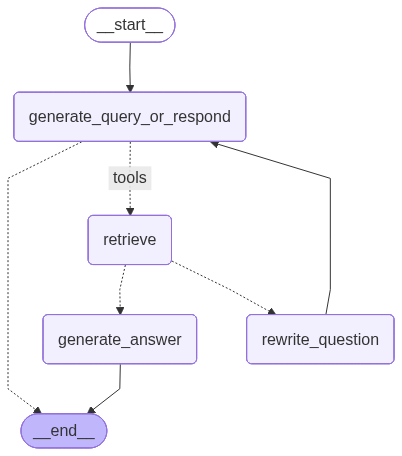

In [19]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(MessagesState)

workflow.add_node(generate_query_or_respond)
workflow.add_node(rewrite_question)
workflow.add_node(generate_answer)
workflow.add_node("retrieve", ToolNode([retrieve_blog_posts]))

workflow.add_edge(START, "generate_query_or_respond")

workflow.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,
    {
        "tools" : "retrieve",
        END : END
    }
)

workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
    # {
    #     "generate_answer" : "generate_answer",
    #     "rewrite_question" : "rewrite_question"
    # }
)

workflow.add_edge("generate_answer", END)
workflow.add_edge("rewrite_question", "generate_query_or_respond")

graph = workflow.compile()
graph

## Agentic RAG 실행

In [20]:
for chunk in graph.stream(
    {'messages' : [('human', 'Lilian Weng은 보상 해킹을 어떻게 정의하는가?')]},
    version='v2'
):
    update = chunk['data']
    for node, node_update in update.items():
        print("Update from node:", node)
        node_update['messages'][-1].pretty_print()
        print('\n\n')

Update from node: generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (call_qlrv6kYFtL2d1urOQzXi7pIz)
 Call ID: call_qlrv6kYFtL2d1urOQzXi7pIz
  Args:
    query: reward hacking



Update from node: retrieve
================================= Tool Message =================================
Name: retrieve_blog_posts

Reward hacking occurs when a reinforcement learning (RL) agent exploits flaws or ambiguities in the reward function to achieve high rewards, without genuinely learning or completing the intended task. Reward hacking exists because RL environments are often imperfect, and it is fundamentally challenging to accurately specify a reward function.

Why does Reward Hacking Exist?#

In-Context Reward Hacking#

Detecting Reward Hacking#



Update from node: generate_answer
================================== Ai Message ==================================

Lilian Weng은 보상 해킹을 강화학습 에이전트가 보상 함수의 결함이나 모호

In [21]:
for chunk in graph.stream(
    {'messages' : [('human', '저녁 뭐 먹을까?')]},
    version='v2'
):
    update = chunk['data']
    for node, node_update in update.items():
        print("Update from node:", node)
        node_update['messages'][-1].pretty_print()
        print('\n\n')

Update from node: generate_query_or_respond
================================== Ai Message ==================================

저녁 메뉴를 고를 때 어떤 종류의 음식을 좋아하는지 알려주시면 추천해드릴게요! 한식, 중식, 일식, 양식 중에 선호하는 게 있나요? 아니면 특별히 먹고 싶은 재료나 음식 스타일이 있나요?





In [22]:
for chunk in graph.stream(
    {'messages' : [('human', 'Lilian Weng은 데이터베이스 인덱스 최적화에 대해서 뭐라고 설명했어?')]},
    version='v2'
):
    update = chunk['data']
    for node, node_update in update.items():
        print("Update from node:", node)
        node_update['messages'][-1].pretty_print()
        print('\n\n')

Update from node: generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (call_zrsH9ywwUI4IJMrsnG6g9COA)
 Call ID: call_zrsH9ywwUI4IJMrsnG6g9COA
  Args:
    query: database index optimization



Update from node: retrieve
================================= Tool Message =================================
Name: retrieve_blog_posts

(2) Run Google search, $K=5$ results per query $q_i$.
(3) Utilize a pretrained query-document relevance model to assign relevance scores and only retain one most relevant $J=1$ document $e_{i1}, \dots, e_{iJ}$ per query $q_i$.

The DDIM update rule is updated accordingly,

Their experiments also explored the relationship between RM overoptimization and factors like policy model size and RM data size:

$$



Update from node: rewrite_question
================================== Ai Message ==================================

사용자의 근본적인 의도는 Lilian Weng이 데이터베이스 인덱스 최적화에 대해 어떤 설명을 했는지